# TS5 - Estimación espectral: ancho de banda de señales reales

Se calcula la densidad espectral de potencia (PSD) de cinco señales del repositorio pdstestbench para estimar su ancho de banda. Para ello, se utilizan tres métodos: periodograma ventaneado, Welch y Blackman-Tukey, aplicados a registros de ECG, PPG, voz y dos silbidos, cada uno con su correspondiente frecuencia de muestreo.

In [1]:
from pathlib import Path

import numpy as np
import scipy.signal as sig
import scipy.io as sio
from scipy.io import wavfile
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.axisbelow': True})

# color fijo por estimador (mismo color = mismo método en todo el trabajo)
COL     = {'per': '#0072B2', 'bt': '#D55E00', 'welch': '#009E73'}
COL_SIG = '#0072B2'   # traza temporal
COL_AUX = '#6b7280'   # líneas auxiliares

# el notebook vive en TS/ y los registros en Extra/TS5/
DATA = next(p for p in (Path('../Extra/TS5'), Path('Extra/TS5'), Path('.'))
            if (p / 'PPG.csv').exists())
print('Registros en:', DATA.resolve())

Registros en: C:\Users\MSI\Desktop\APS\APS-2C\Extra\TS5


In [ ]:
# ---------------- ECG ----------------
fs_ecg = 1000.0
mat    = sio.loadmat(str(DATA / 'ECG_TP4.mat'))
ecg    = mat['ecg_lead'].flatten().astype(float)# cuentas del ADC
t_ecg  = np.arange(len(ecg)) / fs_ecg

# ---------------- PPG ----------------
fs_ppg = 400.0
ppg    = np.genfromtxt(DATA / 'PPG.csv', delimiter=',').astype(float)
t_ppg  = np.arange(len(ppg)) / fs_ppg

# --------------- Audio ---------------
AUDIO = {'Voz (frase)':       'prueba psd.wav',
         'Silbido (melodía)': 'la cucaracha.wav',
         'Silbido (agudo)':   'silbido.wav'}

audio = {}
for nombre, archivo in AUDIO.items():
    fs_a, x = wavfile.read(DATA / archivo)
    x = x.astype(float)
    if x.ndim > 1:
        x = x.mean(axis=1)
    audio[nombre] = (float(fs_a), x, np.arange(len(x)) / fs_a)

# ------------- inventario -------------
SEN = [('ECG', ecg, fs_ecg), ('PPG', ppg, fs_ppg)] + \
      [(n, v[1], v[0]) for n, v in audio.items()]

print(f"{'señal':20s} {'fs [Hz]':>9s} {'N':>10s} {'T [s]':>9s} {'media':>12s} {'desvío':>12s}")
for n, x, fs in SEN:
    print(f'{n:20s} {fs:9.0f} {len(x):10d} {len(x)/fs:9.2f} {x.mean():12.4g} {x.std():12.4g}')

señal                  fs [Hz]          N     T [s]        media       desvío
ECG                       1000    1129116   1129.12        291.8         4915
PPG                        400      45320    113.30   -1.253e+04         3282
Voz (frase)              48000     144000      3.00      0.00811      0.01296
Silbido (melodía)        48000     144000      3.00     0.007981      0.04273
Silbido (agudo)          48000     144000      3.00     0.008169      0.03916


## Señales en el dominio del tiempo

El ECG tiene un registro largo, por lo que se muestra un fragmento para observar su forma y el registro completo reducido para analizar. Como ninguna señal tiene media nula, todas se centran antes de aplicar los estimadores, eliminando su componente continua.

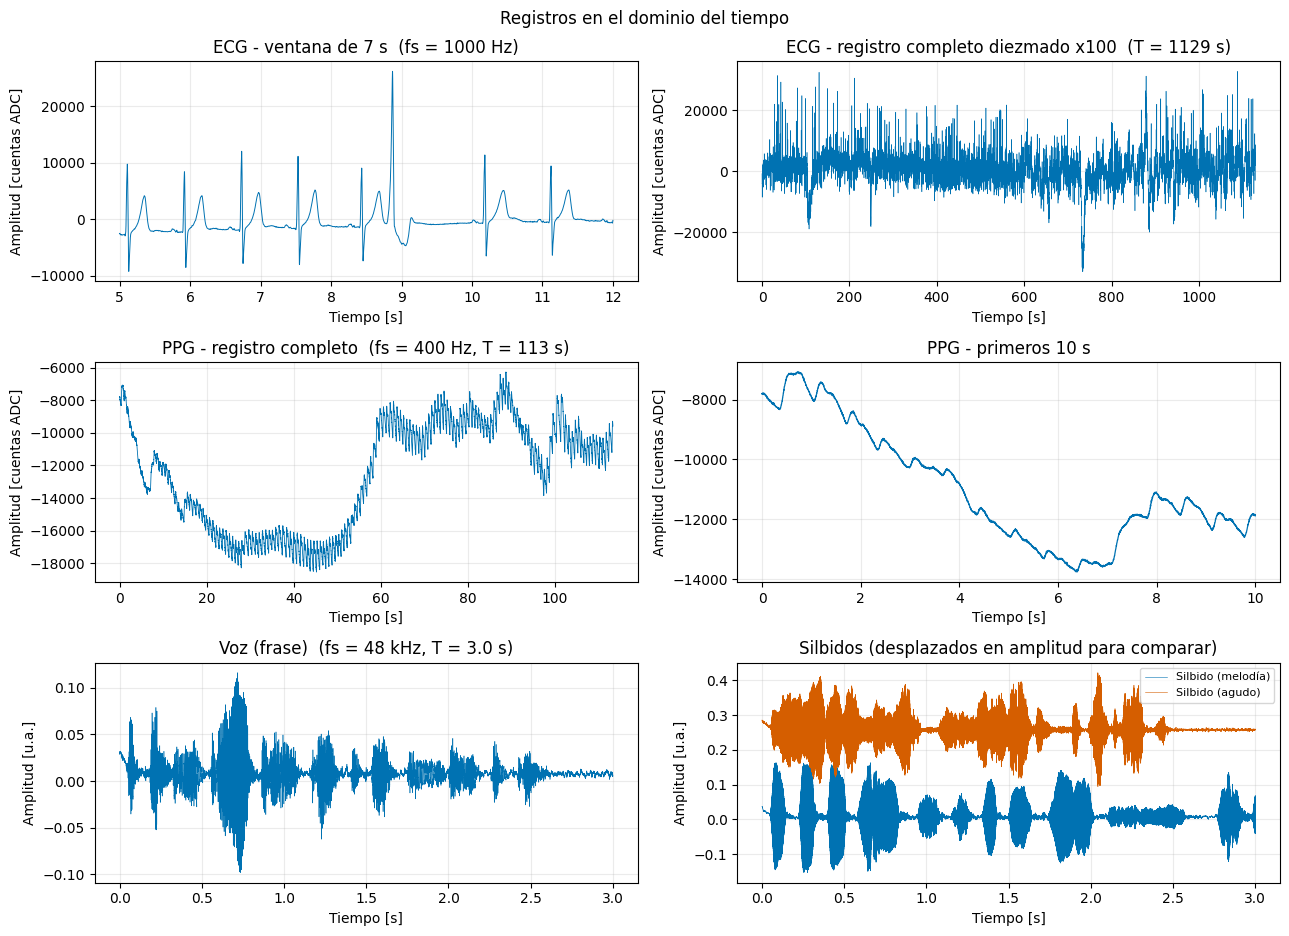

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9.5))
fig.suptitle('Registros en el dominio del tiempo', fontsize=12)

ax = axes[0, 0]
ax.plot(t_ecg[5000:12000], ecg[5000:12000], lw=0.7, color=COL_SIG)
ax.set(title=f'ECG - ventana de 7 s  (fs = {fs_ecg:.0f} Hz)',
       xlabel='Tiempo [s]', ylabel='Amplitud [cuentas ADC]')

ax = axes[0, 1]
ax.plot(t_ecg[::100], ecg[::100], lw=0.4, color=COL_SIG)
ax.set(title=f'ECG - registro completo diezmado x100  (T = {len(ecg)/fs_ecg:.0f} s)',
       xlabel='Tiempo [s]', ylabel='Amplitud [cuentas ADC]')

ax = axes[1, 0]
ax.plot(t_ppg, ppg, lw=0.6, color=COL_SIG)
ax.set(title=f'PPG - registro completo  (fs = {fs_ppg:.0f} Hz, T = {len(ppg)/fs_ppg:.0f} s)',
       xlabel='Tiempo [s]', ylabel='Amplitud [cuentas ADC]')

ax = axes[1, 1]
ax.plot(t_ppg[:int(10*fs_ppg)], ppg[:int(10*fs_ppg)], lw=0.9, color=COL_SIG)
ax.set(title='PPG - primeros 10 s', xlabel='Tiempo [s]', ylabel='Amplitud [cuentas ADC]')

ax = axes[2, 0]
fs_a, x, t_a = audio['Voz (frase)']
ax.plot(t_a, x, lw=0.4, color=COL_SIG)
ax.set(title=f'Voz (frase)  (fs = {fs_a/1000:.0f} kHz, T = {len(x)/fs_a:.1f} s)',
       xlabel='Tiempo [s]', ylabel='Amplitud [u.a.]')

ax = axes[2, 1]
for (nombre, offset), c in zip([('Silbido (melodía)', 0.0), ('Silbido (agudo)', 0.25)],
                               [COL['per'], COL['bt']]):
    fs_a, x, t_a = audio[nombre]
    ax.plot(t_a, x + offset, lw=0.4, color=c, label=nombre)
ax.set(title='Silbidos (desplazados en amplitud para comparar)',
       xlabel='Tiempo [s]', ylabel='Amplitud [u.a.]')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 1. Estimación de la PSD

Periodograma ventaneado. Se aplica una ventana de Hann a todo el registro y se calcula la
DFT. Tiene la mejor resolución posible ($\Delta f = f_s/N$) pero su varianza no baja al
crecer $N$, así que la curva queda muy sucia:

$$\hat S_{PV}(f) = \frac{1}{f_s\,N\,U}\left|\sum_{n=0}^{N-1} x[n]\,w[n]\,e^{-j2\pi f n/f_s}\right|^2,
\qquad U = \frac{1}{N}\sum_{n=0}^{N-1} w^2[n]$$

Welch. Divide el registro en $K$ bloques de $L$ muestras solapados al 50 %, ventanea cada
bloque y promedia los periodogramas. La varianza baja aproximadamente como $1/K$ a costa
de resolución ($\Delta f = f_s/L$):

$$\hat S_W(f) = \frac{1}{K}\sum_{i=0}^{K-1}\hat S_{PV}^{(i)}(f)$$

Blackman-Tukey. Ventanea la autocorrelación estimada, truncándola en $M$ retardos, y la
transforma. El largo $M$ controla el compromiso sesgo-varianza y la resolución queda en el
orden de $f_s/M$:

$$\hat S_{BT}(f) = \frac{1}{f_s}\sum_{k=-M}^{M}\hat r_{xx}[k]\,w[k]\,e^{-j2\pi f k/f_s}$$

In [4]:
def blackman_tukey(x, fs, M=4096, window='blackman', nfft=None):
    """Estimador de Blackman-Tukey de la PSD (densidad, espectro de un lado).

    Parámetros
    ----------
    x : array     señal de entrada
    fs : float    frecuencia de muestreo [Hz]
    M : int       cantidad de retardos conservados de la autocorrelación
    window : str  ventana de retardos (blackman: lóbulos secundarios bajos)
    nfft : int    puntos de la FFT final (por defecto 8*M; sólo interpola la curva)

    Devuelve
    --------
    f, Pxx : vector de frecuencias y PSD estimada
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    N = len(x)
    M = min(M, N - 1)

    # autocorrelación sesgada vía FFT:  r[k] = (1/N) * sum_n x[n] x[n+k]
    n_c = 1 << int(np.ceil(np.log2(2 * N)))
    r   = np.fft.irfft(np.abs(np.fft.rfft(x, n_c)) ** 2, n_c)[:M + 1] / N

    # ventana de retardos, rama 0..M.
    # fftbins=False es obligatorio: la ventana tiene que ser simétrica (par en k),
    # si no la PSD estimada pierde la positividad
    r_w = r * sig.get_window(window, 2 * M + 1, fftbins=False)[M:]

    if nfft is None:
        nfft = 1 << int(np.ceil(np.log2(8 * M)))

    # r[0] en el índice 0 y los retardos negativos al final del buffer:
    # así la secuencia es par respecto del origen y la FFT sale real
    acc = np.zeros(nfft)
    acc[:M + 1]    = r_w
    acc[nfft - M:] = r_w[:0:-1]

    Pxx = 2 * np.fft.rfft(acc).real / fs      # el factor 2 -> espectro de un lado
    f   = np.fft.rfftfreq(nfft, d=1 / fs)
    return f, Pxx

Control del estimador. Para una PSD densidad de un lado tiene que cumplirse
$\int_0^{f_s/2}\hat S(f)\,df \simeq \sigma_x^2$. Se verifica sobre una senoidal de
potencia 1 más ruido de varianza 0,25, y se compara con los dos estimadores de scipy.

In [5]:
fs_t, N_t = 1000.0, 20000
t_t = np.arange(N_t) / fs_t
x_t = np.sqrt(2) * np.sin(2 * np.pi * 100 * t_t) \
      + 0.5 * np.random.default_rng(0).standard_normal(N_t)

for etiqueta, (f_t, P_t) in {
        'Periodograma':   sig.periodogram(x_t, fs=fs_t, window='hann'),
        'Welch':          sig.welch(x_t, fs=fs_t, window='hann', nperseg=1024),
        'Blackman-Tukey': blackman_tukey(x_t, fs_t, M=1024)}.items():
    print(f'{etiqueta:16s} integral de la PSD = {np.trapezoid(P_t, f_t):.4f}')

print(f'{"referencia":16s} varianza de x      = {x_t.var():.4f}   (1.25 teórico)')

Periodograma     integral de la PSD = 1.2390
Welch            integral de la PSD = 1.2441
Blackman-Tukey   integral de la PSD = 1.2438
referencia       varianza de x      = 1.2438   (1.25 teórico)


### Parámetros elegidos

El largo de bloque $L$ de Welch y el $M$ de Blackman-Tukey se eligen para que la
resolución alcance a separar lo que interesa en cada señal: fracciones de Hz en ECG y PPG,
donde el fundamental cardíaco está entre 1 y 3 Hz, y algunas decenas de Hz en audio, donde
los formantes están separados por cientos de Hz.

In [6]:
PARAMS = {'ECG':               dict(nperseg=4096, M=4096),
          'PPG':               dict(nperseg=2048, M=2048),
          'Voz (frase)':       dict(nperseg=4096, M=4096),
          'Silbido (melodía)': dict(nperseg=4096, M=4096),
          'Silbido (agudo)':   dict(nperseg=4096, M=4096)}

psd = {}
for nombre, x, fs in SEN:
    L = PARAMS[nombre]['nperseg']
    psd[nombre] = {
        'fs':    fs,
        'N':     len(x),
        'p':     PARAMS[nombre],
        'K':     max(1, 2 * len(x) // L - 1),
        'per':   sig.periodogram(x, fs=fs, window='hann', scaling='density'),
        'welch': sig.welch(x, fs=fs, window='hann', nperseg=L, noverlap=L // 2,
                           scaling='density'),
        'bt':    blackman_tukey(x, fs, M=PARAMS[nombre]['M']),
    }

print(f"{'señal':20s} {'df period.':>11s} {'df Welch':>10s} {'bloques K':>10s} {'df ~ BT':>10s}")
for nombre, d in psd.items():
    print(f"{nombre:20s} {d['fs']/d['N']:11.4f} {d['fs']/d['p']['nperseg']:10.3f} "
          f"{d['K']:10d} {d['fs']/d['p']['M']:10.3f}")

señal                 df period.   df Welch  bloques K    df ~ BT
ECG                       0.0009      0.244        550      0.244
PPG                       0.0088      0.195         43      0.195
Voz (frase)               0.3333     11.719         69     11.719
Silbido (melodía)         0.3333     11.719         69     11.719
Silbido (agudo)           0.3333     11.719         69     11.719


### PSD estimada

En cada figura se superponen los tres estimadores sobre la misma señal, en escala
logarítmica: a la izquierda toda la banda hasta Nyquist y a la derecha un zoom sobre la
zona donde está la potencia.

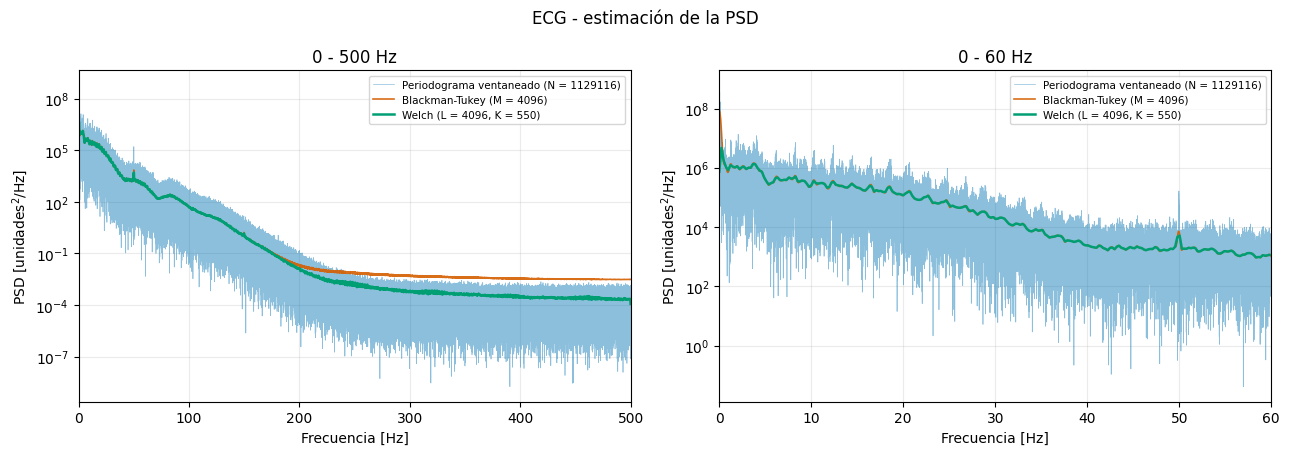

In [7]:
def plot_psd(nombre, f_max_izq, f_max_der):
    """Superpone los tres estimadores de una señal en dos rangos de frecuencia."""
    d = psd[nombre]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    fig.suptitle(f'{nombre} - estimación de la PSD', fontsize=12)

    curvas = [('per',   d['per'],   f"Periodograma ventaneado (N = {d['N']})",        0.5, 0.45),
              ('bt',    d['bt'],    f"Blackman-Tukey (M = {d['p']['M']})",            1.2, 0.90),
              ('welch', d['welch'], f"Welch (L = {d['p']['nperseg']}, K = {d['K']})", 1.8, 1.00)]

    for ax, f_max in zip(axes, (f_max_izq, f_max_der)):
        for clave, (f, P), etiqueta, lw, alpha in curvas:
            m = f <= f_max
            ax.semilogy(f[m], np.maximum(P[m], 1e-20), lw=lw, alpha=alpha,
                        color=COL[clave], label=etiqueta)
        ax.set(xlabel='Frecuencia [Hz]', ylabel='PSD [unidades$^2$/Hz]',
               title=f'0 - {f_max:g} Hz', xlim=(0, f_max))
        ax.legend(fontsize=7.5, loc='upper right')

    plt.tight_layout()
    plt.show()


plot_psd('ECG', fs_ecg / 2, 60)

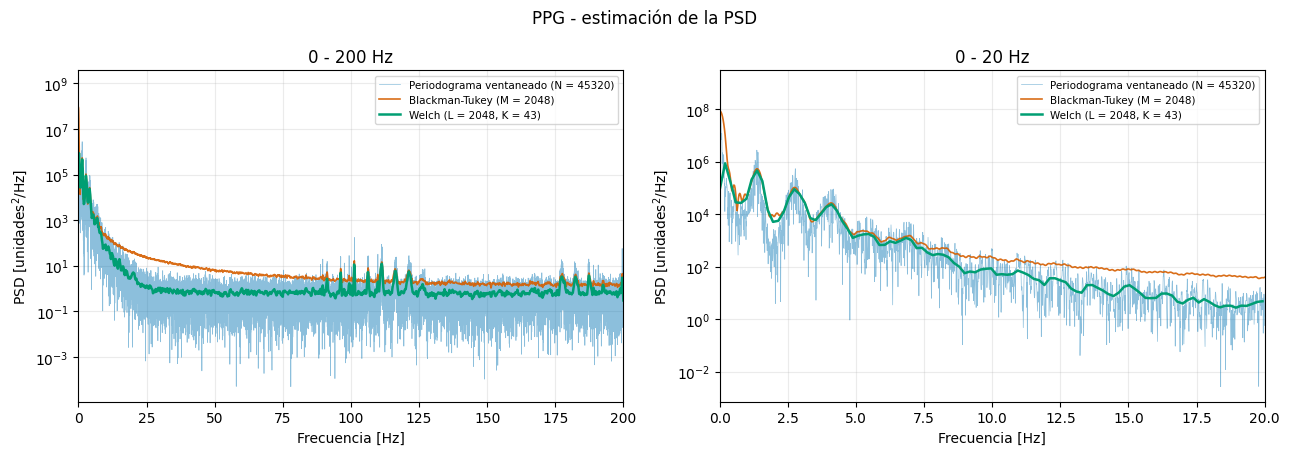

In [8]:
plot_psd('PPG', fs_ppg / 2, 20)

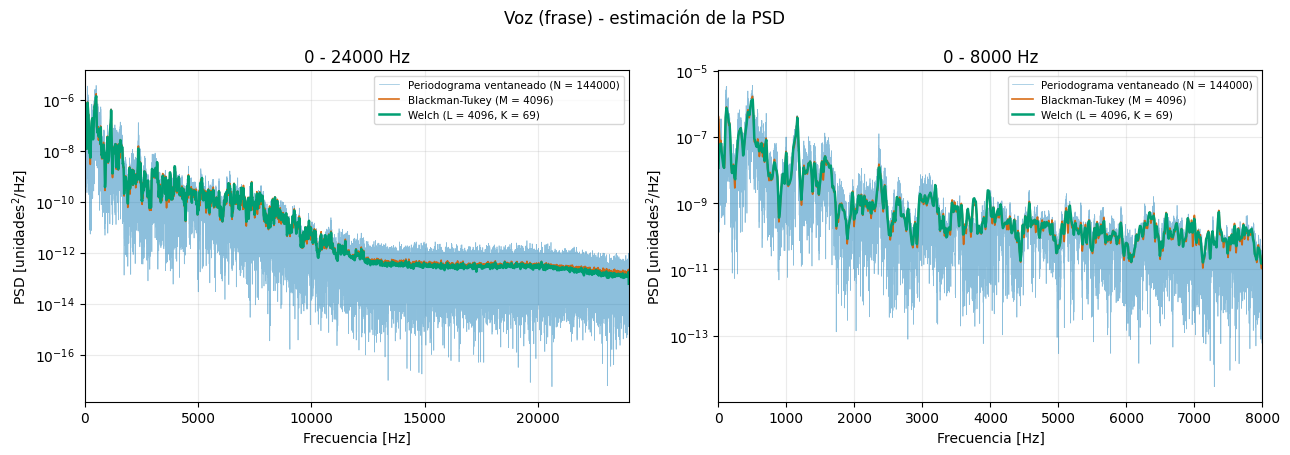

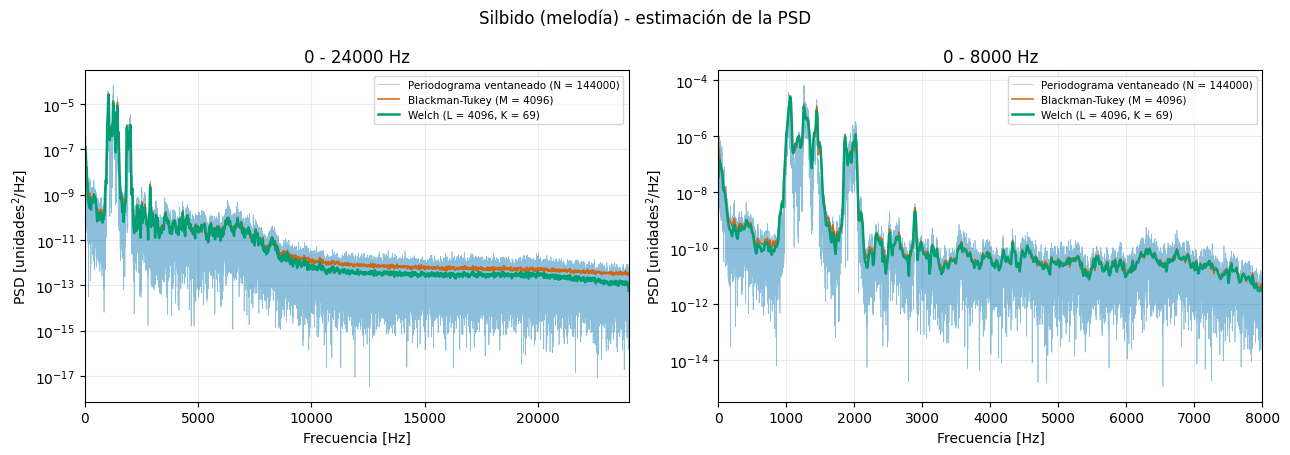

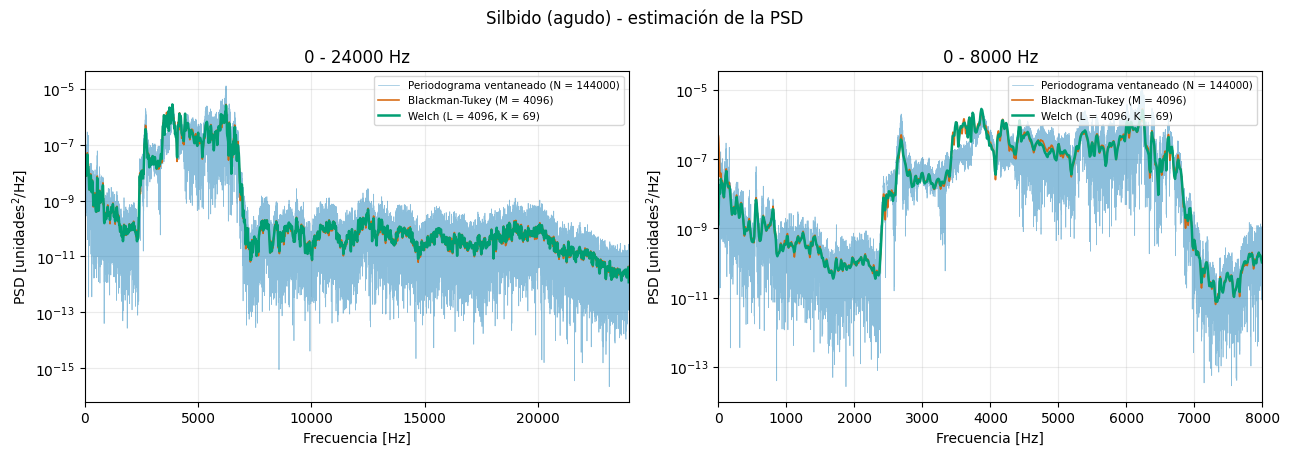

In [9]:
for nombre in ['Voz (frase)', 'Silbido (melodía)', 'Silbido (agudo)']:
    plot_psd(nombre, 24000, 8000)

### Comparación de los estimadores

El periodograma presenta muchas fluctuaciones, mientras que Welch genera una curva más suave y fácil de interpretar. Blackman-Tukey ofrece un resultado intermedio, reduciendo las fluctuaciones sin perder demasiada información.

En ECG y PPG, Welch reduce la deriva de la señal, por lo que muestra menos potencia en bajas frecuencias. En el ECG, Blackman-Tukey presenta más potencia en altas frecuencias debido a limitaciones del método y no a la presencia de señal real.

Por estas razones, se utiliza Welch para estimar el ancho de banda, ya que proporciona resultados más estables y representa mejor el comportamiento de la señal.

## 2. Estimación del ancho de banda

Se usan dos criterios, los dos basados en potencia acumulada.

Ancho de banda desde continua: la frecuencia por debajo de la cual se acumula una fracción
$p$ de la potencia total,

$$f_p = \min\left\{ f : \int_0^{f}\hat S(\nu)\,d\nu \ \ge\ p \int_0^{f_s/2}\hat S(\nu)\,d\nu \right\}$$

Sirve para señales pasabajo (ECG, PPG, voz) y es el número que se usa para elegir el filtro
antialias o la frecuencia de muestreo.

Banda ocupada: el intervalo $[f_{inf}, f_{sup}]$ que contiene la fracción $p$ de la potencia
dejando $(1-p)/2$ afuera de cada lado, con $BW = f_{sup}-f_{inf}$. Este criterio es el que
hace falta para las señales pasabanda: un silbido concentra la potencia en una banda angosta
alrededor de su fundamental, y medirlo desde continua da un número engañosamente grande.

Se reportan $p = 0{,}95$ y $p = 0{,}99$.

In [10]:
def acumulada(f, Pxx):
    """Potencia acumulada normalizada y potencia total."""
    P_cum = np.cumsum(np.maximum(Pxx, 0)) * (f[1] - f[0])
    return P_cum / P_cum[-1], P_cum[-1]


def bw_desde_dc(f, Pxx, p):
    """Frecuencia por debajo de la cual se acumula la fracción p de la potencia."""
    c, _ = acumulada(f, Pxx)
    return f[min(np.searchsorted(c, p), len(f) - 1)]


def banda_ocupada(f, Pxx, p):
    """Intervalo [f_inf, f_sup] que contiene la fracción p de la potencia."""
    c, _  = acumulada(f, Pxx)
    i_inf = max(np.searchsorted(c, (1 - p) / 2) - 1, 0)
    i_sup = min(np.searchsorted(c, (1 + p) / 2), len(f) - 1)
    return f[i_inf], f[i_sup]


P_NIVELES = (0.95, 0.99)

bw = {}
for nombre, d in psd.items():
    f, P     = d['welch']
    _, P_tot = acumulada(f, P)
    bw[nombre] = {
        'fs':     d['fs'],
        'f_pico': f[np.argmax(P)],
        'P_tot':  P_tot,
        'dc':     {p: bw_desde_dc(f, P, p)   for p in P_NIVELES},
        'ocup':   {p: banda_ocupada(f, P, p) for p in P_NIVELES},
    }

print('Anchos de banda calculados sobre la PSD de Welch.')

Anchos de banda calculados sobre la PSD de Welch.


In [11]:
def tabla(headers, rows, titulo):
    """Imprime una tabla de texto con las columnas centradas."""
    w   = [max(len(h), max(len(r[i]) for r in rows)) + 2 for i, h in enumerate(headers)]
    sep = '+' + '+'.join('-' * c for c in w) + '+'
    fmt = '|' + '|'.join(f'{{:^{c}}}' for c in w) + '|'
    print(f'\n{titulo}')
    print(sep)
    print(fmt.format(*headers))
    print(sep)
    for r in rows:
        print(fmt.format(*r))
    print(sep)


def fmt_hz(v):
    return f'{v:.2f}' if v < 100 else f'{v:.0f}'


headers = ['Señal', 'fs [Hz]', 'f pico [Hz]', 'BW 95% desde DC [Hz]',
           'BW 99% desde DC [Hz]', 'Banda ocupada 99% [Hz]', 'BW ocupado 99% [Hz]']
rows = []
for nombre, b in bw.items():
    f_inf, f_sup = b['ocup'][0.99]
    rows.append([nombre,
                 f"{b['fs']:.0f}",
                 fmt_hz(b['f_pico']),
                 fmt_hz(b['dc'][0.95]),
                 fmt_hz(b['dc'][0.99]),
                 f'{fmt_hz(f_inf)} - {fmt_hz(f_sup)}',
                 fmt_hz(f_sup - f_inf)])

tabla(headers, rows, 'Ancho de banda por contenido de potencia (estimador de Welch)')


Ancho de banda por contenido de potencia (estimador de Welch)
+-------------------+---------+-------------+----------------------+----------------------+------------------------+---------------------+
|       Señal       | fs [Hz] | f pico [Hz] | BW 95% desde DC [Hz] | BW 99% desde DC [Hz] | Banda ocupada 99% [Hz] | BW ocupado 99% [Hz] |
+-------------------+---------+-------------+----------------------+----------------------+------------------------+---------------------+
|        ECG        |  1000   |    0.24     |        21.97         |        31.01         |      0.00 - 37.11      |        37.11        |
|        PPG        |   400   |    0.20     |         3.12         |         4.49         |      0.00 - 5.66       |        5.66         |
|    Voz (frase)    |  48000  |     504     |         1172         |         2637         |      11.72 - 3938      |        3926         |
| Silbido (melodía) |  48000  |    1055     |         1488         |         2016         |       973 -

### Potencia acumulada

La potencia acumulada normalizada muestra de dónde salen los números de la tabla: una subida
abrupta indica potencia concentrada, y una subida lenta indica energía repartida en
frecuencia. Las líneas punteadas marcan los niveles del 95 % y del 99 %.

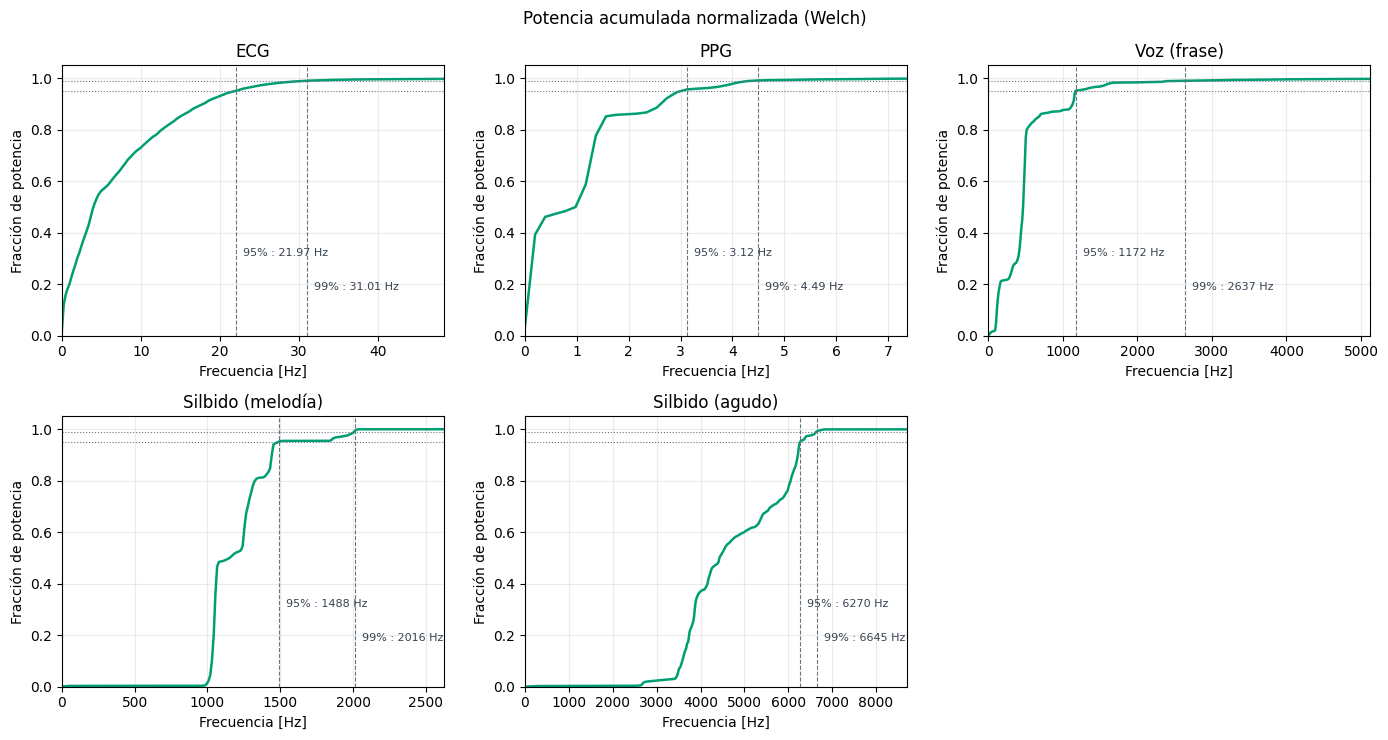

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
fig.suptitle('Potencia acumulada normalizada (Welch)', fontsize=12)

for ax, (nombre, d) in zip(axes.flat, psd.items()):
    f, P  = d['welch']
    c, _  = acumulada(f, P)
    f_sup = bw[nombre]['ocup'][0.99][1]

    ax.plot(f, c, lw=1.8, color=COL['welch'])
    for k, p in enumerate(P_NIVELES):
        f_p = bw[nombre]['dc'][p]
        ax.axhline(p,   color=COL_AUX, lw=0.8, ls=':')
        ax.axvline(f_p, color=COL_AUX, lw=0.8, ls='--')
        # etiquetas escalonadas en altura para que no se pisen entre sí
        ax.annotate(f'{p*100:.0f}% : {fmt_hz(f_p)} Hz', xy=(f_p, 0.32 - 0.13 * k),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=8, color='#374151', ha='left', va='center')

    ax.set(title=nombre, xlabel='Frecuencia [Hz]', ylabel='Fracción de potencia',
           xlim=(0, f_sup * 1.3), ylim=(0, 1.05))

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

### Análisis de los resultados

 ECG: La mayor parte de la energía está por debajo de 30 Hz. Las variaciones por respiración y movimiento generan componentes de muy baja frecuencia, mientras que los latidos aportan contenido hasta frecuencias mayores.

 PPG: Es la señal más lenta, con la energía concentrada en el ritmo cardíaco y sus armónicos. Su ancho de banda es de unos 5 Hz, por lo que muestrear a 400 Hz resulta excesivo; con 50 Hz sería suficiente.

 Voz: Es la señal con mayor ancho de banda entre las señales pasabajo. La mayor parte de la energía está por debajo de 1,2 kHz, aunque para conservar los sonidos más agudos se necesitan unos 2,6 kHz.

 Silbidos: Son señales casi tonales, con energía concentrada alrededor de una frecuencia. El silbido agudo parece tener mayor ancho de banda porque está a una frecuencia más alta, pero su banda ocupada es menor. En ambos casos, muestrear a 48 kHz es suficiente.

Conclusión: El ancho de banda depende del criterio utilizado para medirlo. En señales pasabajo ambos criterios dan resultados similares, mientras que en señales pasabanda, como los silbidos, pueden dar valores muy diferentes.